## Generazione di immagini rumorose con rumore gaussiano
In questo notebook viene costruita una versione degradata dei dataset di immagini utilizzando **rumore gaussiano additivo**.  
L’obiettivo è simulare una delle forme più comuni di degradazione nelle immagini digitali, in cui a ciascun pixel viene aggiunta una perturbazione casuale estratta da una distribuzione normale.

Il rumore gaussiano può essere modellato come:

$$
x = s + n
$$

dove:

- \(s\) rappresenta l’immagine originale pulita;
- \(n\) rappresenta il rumore gaussiano;
- \(x\) rappresenta l’immagine osservata rumorosa.

Nel caso considerato, il rumore viene generato con **media nulla** e deviazione standard $\sigma = 25$:
$$
n \sim \mathcal{N}(0, \sigma^2)
$$

La scelta di una media pari a zero è coerente con l’assunzione teorica secondo cui il valore atteso del rumore non altera il valore medio del segnale originale. In altre parole, mediando molte realizzazioni indipendenti dello stesso rumore, il contributo rumoroso tende ad annullarsi.

Il notebook segue una procedura generale composta da quattro fasi principali:

1. caricamento delle immagini originali dai dataset;
2. applicazione del rumore gaussiano tramite OpenCV;
3. salvataggio delle immagini rumorose su disco;
4. visualizzazione e confronto tra immagine originale e immagine degradata.

Le immagini generate potranno poi essere utilizzate come input per successive sperimentazioni di **image denoising**, in particolare nell’ambito di metodi di deep learning come Noise2Noise e Noise2Void.

## About Dataset

In questo notebook vengono utilizzati tre dataset di immagini naturali comunemente impiegati in attività di **image restoration**, **image denoising** e valutazione della qualità visiva: **Kodak**, **BSD500** e **DIV2K**.

L’obiettivo è partire da immagini pulite e generare, per ciascun dataset, una versione degradata tramite rumore gaussiano additivo. Le immagini rumorose vengono poi salvate su disco mantenendo, quando presente, la struttura originale delle sottocartelle.

| Dataset | Numero di immagini | Struttura | Caratteristiche principali |
|---|---:|---|---|
| **Kodak Dataset** | 24 immagini | immagini contenute in un’unica cartella | immagini RGB di alta qualità, non compresse o poco degradate, spesso usate come riferimento per valutare algoritmi di denoising e compressione |
| **BSD500** | 500 immagini | suddiviso in sottocartelle: `train`, `test` e `val` | immagini naturali RGB con scene varie |
| **DIV2K** | 900 immagini| immagini ad alta risoluzione, organizzate in cartelle del dataset Kaggle | immagini RGB ad alta qualità e alta risoluzione |

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import cv2 #opencv
import matplotlib.pyplot as plt #visualizzazione immagini
from pathlib import Path
from tqdm import tqdm 
from skimage.metrics import peak_signal_noise_ratio as psnr #calcolo PSNR
import shutil


#for dirname, _, filenames in os.walk('/kaggle/input'):
 #   for filename in filenames:
  #      print(os.path.join(dirname, filename))

In [2]:
def add_gaussian_noise_opencv(image, mean=0, sigma=25):
    """
    Aggiunge rumore gaussiano additivo usando OpenCV.

    image: immagine uint8 in [0, 255]
    mean: media del rumore gaussiano
    sigma: deviazione standard del rumore gaussiano

    Per immagini a colori OpenCV usa ordine BGR.
    Quindi mean e sigma vengono esplicitati sui 3 canali.
    """

    image_float = image.astype(np.float32) #conversione in float

    noise = np.zeros_like(image_float, dtype=np.float32) #array del rumore
#Immagine a colori
    if len(image.shape) == 3:
        cv2.randn( #a ciascuna componente viene assegnato rumore diverso(BGR)
            noise,
            (mean, mean, mean),
            (sigma, sigma, sigma)
        )
    else:
        cv2.randn(
            noise,
            mean,
            sigma
        )

    noisy_image = image_float + noise #aggiunta del rumore gaussiano
    noisy_image = np.clip(noisy_image, 0, 255) #ritorno in [0,255]

    return noisy_image.astype(np.uint8) #ritorno in uint8

In [3]:
def create_gaussian_noisy_dataset(input_dir, output_dir, mean=0, sigma=25):
    """
    Crea un dataset rumoroso applicando rumore gaussiano a tutte le immagini
    contenute in input_dir e salvandole direttamente in output_dir.

    input_dir: cartella contenente le immagini pulite
    output_dir: cartella dove salvare le immagini rumorose
    mean: media del rumore gaussiano
    sigma: deviazione standard del rumore gaussiano

    Ritorna:
    - image_paths: lista delle immagini originali lette
    - processed_images: lista dei nomi delle immagini processate
    - psnr_values: lista dei PSNR clean/noisy
    """

    #percorsi di input e output
    input_dir = Path(input_dir)
    output_dir = Path(output_dir)

    output_dir.mkdir(parents=True, exist_ok=True)#creazione cartella output

    image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]
#ricostruisce la cartella input
    image_paths = [
        p for p in input_dir.rglob("*")
        if p.suffix.lower() in image_extensions
    ]

    image_paths = sorted(image_paths)

    print("Cartella input:", input_dir)
    print("Cartella output:", output_dir)
    print("Immagini trovate:", len(image_paths))

    psnr_values = [] #valori psnr
    processed_images = []

    for img_path in tqdm(image_paths): #barra di avanzamento
        image = cv2.imread(str(img_path), cv2.IMREAD_COLOR) #legge immagine a colori

        if image is None:
            print("Immagine non letta:", img_path)
            continue

        #applicazione rumore gaussiano
        noisy_image = add_gaussian_noise_opencv(
            image,
            mean=mean,
            sigma=sigma
        )
        
        relative_path = img_path.relative_to(input_dir) #percorso dell'immagine
        save_path = output_dir / relative_path #percorso finale immagine 
        save_path.parent.mkdir(parents=True, exist_ok=True) 

        success = cv2.imwrite(str(save_path), noisy_image) #salvataggio immagine su disco

        if not success:
            print("Errore nel salvataggio:", save_path)
            continue

        value = psnr(image, noisy_image, data_range=255) #psnr

        psnr_values.append(value) 
        processed_images.append(img_path.name)

    print("Immagini processate:", len(processed_images))

    if len(psnr_values) > 0: #riepilogo valori della cartella
        print("PSNR medio clean/noisy:", np.mean(psnr_values))
        print("PSNR minimo:", np.min(psnr_values))
        print("PSNR massimo:", np.max(psnr_values))

    return image_paths, processed_images, psnr_values

## Valutazione tramite PSNR

Per quantificare il livello di degradazione introdotto dal rumore viene calcolato il **PSNR**, acronimo di **Peak Signal-to-Noise Ratio**.

Il PSNR è una metrica molto utilizzata nell'elaborazione delle immagini per confrontare un'immagine degradata con la corrispondente immagine di riferimento. Nel nostro caso, il confronto viene effettuato tra:

- l'immagine originale pulita;
- l'immagine rumorosa generata artificialmente.

Il PSNR è espresso in **decibel (dB)** e dipende dall'errore quadratico medio tra le due immagini. In generale:

$$
PSNR = 10 \cdot \log_{10}\left(\frac{MAX_I^2}{MSE}\right)
$$

dove:

- $MAX_I$ è il valore massimo possibile di intensità del pixel, pari a 255 per immagini a 8 bit;
- $MSE$ è il Mean Squared Error tra immagine originale e immagine degradata.


- un **PSNR alto** indica che l'immagine rumorosa è molto simile all'immagine originale;
- un **PSNR basso** indica che il rumore ha introdotto una degradazione più forte;
- se due immagini sono identiche, il MSE è pari a zero e il PSNR tende teoricamente a infinito.

In [4]:
def show_single_image(image_path, figsize=(8, 6), title=None):
    """
    Visualizza una singola immagine.

    image_path: percorso dell'immagine da visualizzare
    figsize: dimensione della figura
    title: titolo opzionale; se None usa il nome del file
    """

    image_path = Path(image_path)

    img = cv2.imread(str(image_path), cv2.IMREAD_COLOR)

    if img is None:
        print("Errore: immagine non letta.")
        print("Controlla che il file esista:", image_path)
        print("Esiste:", image_path.exists())
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=figsize)
    plt.imshow(img_rgb)
    plt.axis("off")

    if title is None:
        plt.title(image_path.name)
    else:
        plt.title(title)

    plt.show()

In [5]:
def show_clean_noisy_pair(image_paths, output_dir, index=0):
    """
    Visualizza un'immagine pulita e la corrispondente immagine rumorosa salvata.

    image_paths: lista delle immagini originali
    output_dir: cartella dove sono state salvate le immagini rumorose
    index: indice dell'immagine da visualizzare
    """

    output_dir = Path(output_dir)

    if len(image_paths) == 0:
        print("Nessuna immagine originale disponibile.")
        return

    if index >= len(image_paths):
        print("Indice fuori range.")
        return

    clean_path = image_paths[index]
    noisy_path = output_dir / clean_path.name

    print("Originale:", clean_path)
    print("Rumorosa:", noisy_path)

    clean = cv2.imread(str(clean_path), cv2.IMREAD_COLOR)
    noisy = cv2.imread(str(noisy_path), cv2.IMREAD_COLOR)

    if clean is None:
        print("Errore: immagine originale non letta.")
        return

    if noisy is None:
        print("Errore: immagine rumorosa non letta.")
        print("Controlla che esista:", noisy_path.exists())
        return

    clean_rgb = cv2.cvtColor(clean, cv2.COLOR_BGR2RGB)
    noisy_rgb = cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(clean_rgb)
    plt.title("Immagine originale")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(noisy_rgb)
    plt.title("Rumore gaussiano σ=25")
    plt.axis("off")

    plt.show()

    print("PSNR clean/noisy:", psnr(clean, noisy, data_range=255))

In [6]:
kodak_image_paths, kodak_processed, kodak_psnr = create_gaussian_noisy_dataset(
    input_dir="/kaggle/input/datasets/sherylmehta/kodak-dataset",
    output_dir="/kaggle/working/kodak_gaussian_sigma25",
    mean=0,
    sigma=25
)

Cartella input: /kaggle/input/datasets/sherylmehta/kodak-dataset
Cartella output: /kaggle/working/kodak_gaussian_sigma25
Immagini trovate: 24


100%|██████████| 24/24 [00:01<00:00, 13.21it/s]

Immagini processate: 24
PSNR medio clean/noisy: 20.438355791787146
PSNR minimo: 20.2036756450277
PSNR massimo: 21.398713808245148


Originale: /kaggle/input/datasets/sherylmehta/kodak-dataset/kodim01.png
Rumorosa: /kaggle/working/kodak_gaussian_sigma25/kodim01.png


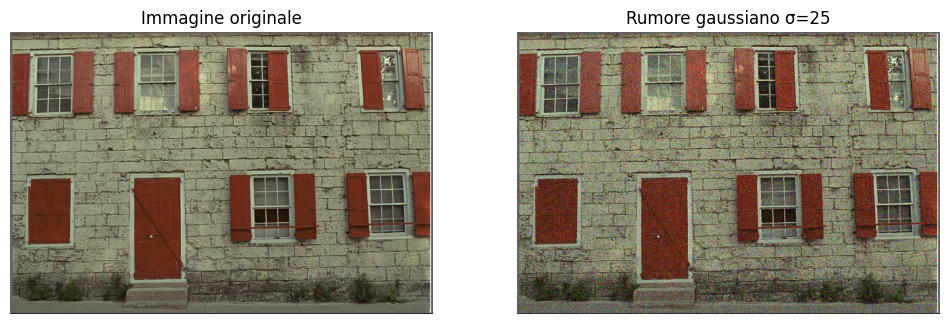

PSNR clean/noisy: 20.27440647881631


In [7]:
show_clean_noisy_pair(
    image_paths=kodak_image_paths,
    output_dir="/kaggle/working/kodak_gaussian_sigma25",
    index=0
)

In [8]:
bsd_image_paths, bsd_processed, bsd_psnr = create_gaussian_noisy_dataset(
    "/kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/images",
    "/kaggle/working/bsd500_gaussian_sigma25",
    sigma=25
)

Cartella input: /kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/images
Cartella output: /kaggle/working/bsd500_gaussian_sigma25
Immagini trovate: 500


100%|██████████| 500/500 [00:07<00:00, 66.61it/s]

Immagini processate: 500
PSNR medio clean/noisy: 20.53238124532488
PSNR minimo: 20.170857131533587
PSNR massimo: 22.37496455115953


Originale: /kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/images/test/100007.jpg
Rumorosa: /kaggle/working/bsd500_gaussian_sigma25/test/100007.jpg


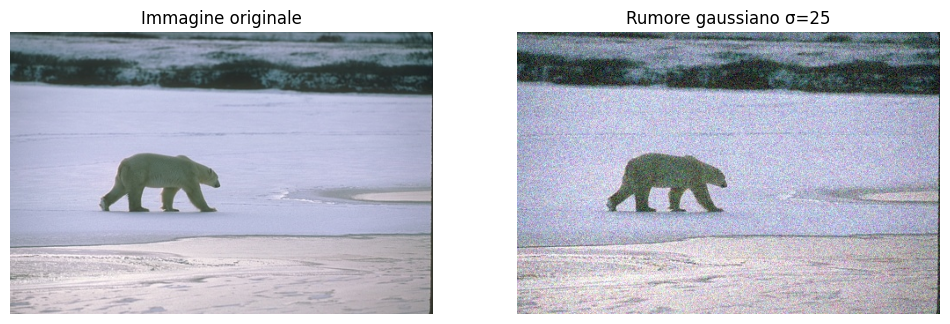

PSNR clean/noisy: 23.251708445347973


In [9]:
show_clean_noisy_pair(
    image_paths=bsd_image_paths,
    output_dir="/kaggle/working/bsd500_gaussian_sigma25/test",
    index=0
)

In [10]:
shutil.rmtree("/kaggle/working/div2k_gaussian_sigma25", ignore_errors=True)
div2k_image_path , div2k_images, div2k_psnr = create_gaussian_noisy_dataset(
    "/kaggle/input/datasets/soumikrakshit/div2k-high-resolution-images/",
    "/kaggle/working/div2k_gaussian_sigma25",
    mean=0,
    sigma=25
)

Cartella input: /kaggle/input/datasets/soumikrakshit/div2k-high-resolution-images
Cartella output: /kaggle/working/div2k_gaussian_sigma25
Immagini trovate: 900


100%|██████████| 900/900 [06:48<00:00,  2.20it/s]

Immagini processate: 900
PSNR medio clean/noisy: 20.67526470138715
PSNR minimo: 20.200528302127175
PSNR massimo: 22.449765857839502


Originale: /kaggle/input/datasets/soumikrakshit/div2k-high-resolution-images/DIV2K_train_HR/DIV2K_train_HR/0002.png
Rumorosa: /kaggle/working/div2k_gaussian_sigma25/DIV2K_train_HR/DIV2K_train_HR/0002.png


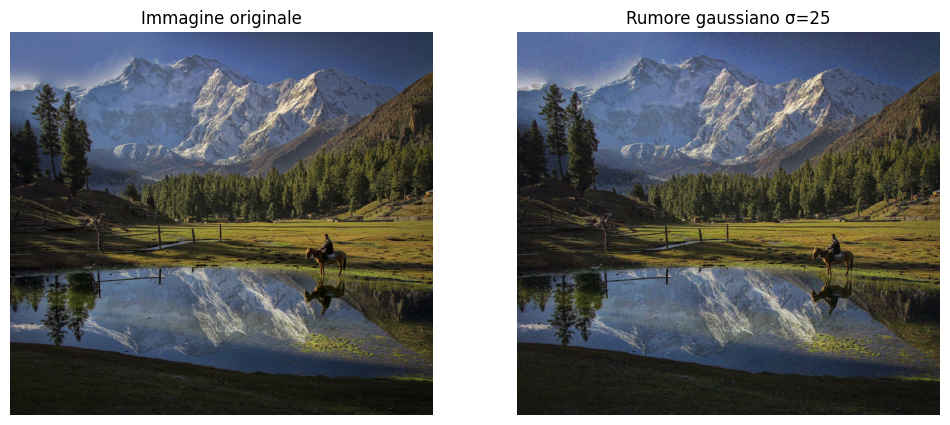

PSNR clean/noisy: 20.61904601328881


In [11]:
show_clean_noisy_pair(
    image_paths=div2k_image_path,
    output_dir="/kaggle/working/div2k_gaussian_sigma25/DIV2K_train_HR/DIV2K_train_HR",
    index=1
)